In [35]:
import import_ipynb
import sys
import warnings
from contextlib import redirect_stdout

from sklearn.model_selection import train_test_split
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [73]:
from sklearn.linear_model import LogisticRegression as lr
from sklearn.tree import DecisionTreeClassifier as dt , plot_tree
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.linear_model import LinearRegression as linear

# import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
import numpy as np

In [38]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, ConfusionMatrixDisplay,
classification_report , roc_curve, roc_auc_score
)


from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [39]:
from sklearn.model_selection import GridSearchCV as gscv

In [40]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score as r2s


In [91]:
import joblib

# Part B — Predictive modeling, continuing from the same cleaned data


## data split

In [41]:
try:
    raw_titanic_data=sns.load_dataset("titanic")
    # print(raw_titanic_data.head())
except:
    raw_titanic_data=pd.read_csv("input_data/titanic.csv")

In [42]:
x = raw_titanic_data.drop("survived", axis=1)
y = raw_titanic_data["survived"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42, stratify=y)

Stratify is basically a parameter that ensures the preservation of proportion in data. "Stratify =y" means that "maintain the proportion of survivors and death rate as in original dataset."

So, for example, if the original data set has 30% survivors and 60% death rate, same proportion must be reflected in train and test data. 

## Preprocessing

In [43]:
numeric_features = [ "age", "fare",  "sibsp",  "parch"]
categorical_features = ["sex",    "embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [44]:
# x_train_processed = preprocessor.fit_transform(x_train)

# x_test_processed = preprocessor.transform(x_test)

## Training 3 models

In [45]:
# lr_model = lr(max_iter=1000)
# lr_model.fit(x_train, y_train)
# lr_y_train_pred = lr_model.predict(x_train)
# lr_y_test_pred = lr_model.predict(x_test)
# lr_y_test_prob = lr_model.predict_proba(x_test)[:1]

In [46]:

# dt_model = dt()
# dt_model.fit(x_train, y_train)
# dt_y_train_pred = dt_model.predict(x_train)
# dt_y_test_pred = dt_model.predict(x_test)

In [47]:
# rf_model = rf()
# rf_model.fit(x_train, y_train)

# rf_y_train_pred=rf_model.predict(x_train)
# rf_y_test_pred = rf_model.predict(x_test)

In [48]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lr(random_state=42, max_iter=1000))
])

lr_model.fit(x_train, y_train)

lr_y_pred = lr_model.predict(x_test)
lr_y_proba = lr_model.predict_proba(x_test)[:,1]

In [49]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", dt(random_state=42))
])

dt_model.fit(x_train, y_train)

dt_y_pred = dt_model.predict(x_test)
dt_y_proba = dt_model.predict_proba(x_test)[:,1]


In [50]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf(random_state=42))
])

rf_model.fit(x_train, y_train)

rf_y_pred = rf_model.predict(x_test)
rf_y_proba = rf_model.predict_proba(x_test)[:,1]

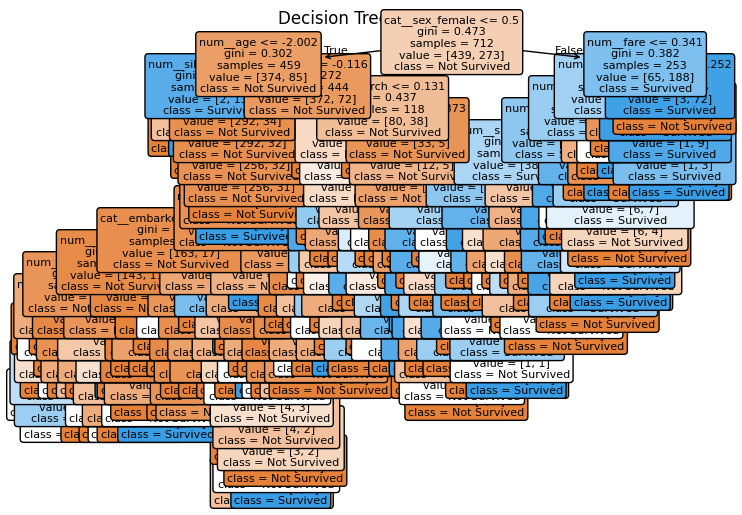

In [51]:
feature_names = (
    dt_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

tree_model = dt_model.named_steps["classifier"]

# print(plt)
# print(plt.figure)
# print(type(plt.figure))

plt.figure(figsize=(8, 6))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.show()

## Evaluation of all 3 models

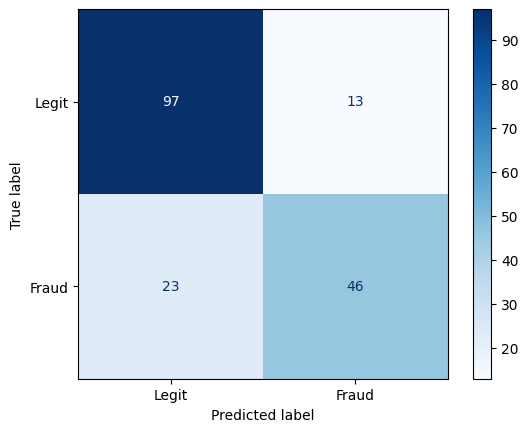

In [52]:
lr_confusion_matrix = confusion_matrix(y_test, lr_y_pred)
tn, fp, fn, tp = lr_confusion_matrix.ravel()   # flattened order: TN, FP, FN, TP
ConfusionMatrixDisplay.from_predictions(
y_test, lr_y_pred,
display_labels=['Legit', 'Fraud'],
cmap='Blues'
)


lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_precession = precision_score (y_test, lr_y_pred)
lr_recall = recall_score (y_test, lr_y_pred)
lr_f1_score = f1_score(y_test, lr_y_pred)
lr_fpr, lr_tpr, lr_threshold = roc_curve(y_test, lr_y_proba)
lr_auc= roc_auc_score (y_test, lr_y_proba)

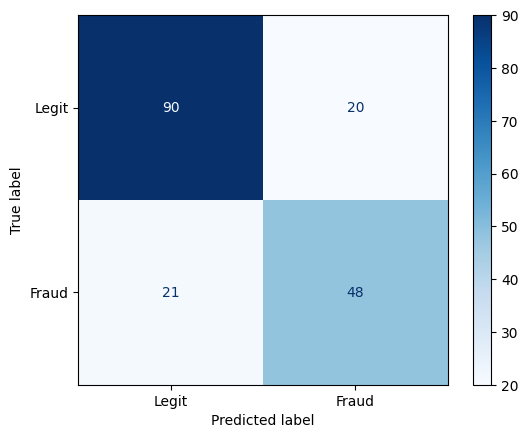

In [53]:
dt_confusion_matrix = confusion_matrix(y_test, dt_y_pred)
tn, fp, fn, tp = dt_confusion_matrix.ravel()   # flattened order: TN, FP, FN, TP
ConfusionMatrixDisplay.from_predictions(
y_test, dt_y_pred,
display_labels=['Legit', 'Fraud'],
cmap='Blues'
)

dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precession = precision_score (y_test, dt_y_pred)
dt_recall = recall_score (y_test, dt_y_pred)
dt_f1_score = f1_score(y_test, dt_y_pred)
dt_fpr, dt_tpr, dt_threshold =roc_curve(y_test, dt_y_proba)
dt_auc= roc_auc_score (y_test, dt_y_proba)

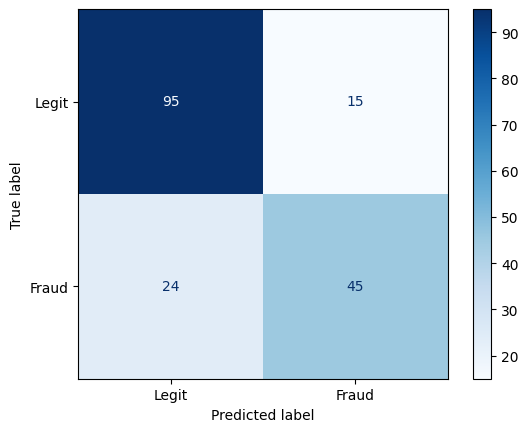

In [54]:
rf_confusion_matrix = confusion_matrix(y_test, rf_y_pred)
tn, fp, fn, tp = rf_confusion_matrix.ravel()   # flattened order: TN, FP, FN, TP
ConfusionMatrixDisplay.from_predictions(
y_test, rf_y_pred,
display_labels=['Legit', 'Fraud'],
cmap='Blues'
)

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precession = precision_score (y_test, rf_y_pred)
rf_recall = recall_score (y_test, rf_y_pred)
rf_f1_score = f1_score(y_test, rf_y_pred)
rf_fpr, rf_tpr, rf_threshold =roc_curve(y_test, rf_y_proba)
rf_auc= roc_auc_score (y_test, rf_y_proba)

In [55]:
columns=('Model','Accuracy', 'Precession', 'Recall', 'F1_score', 'AUC')
values_before=[['Random Forest',rf_accuracy, rf_precession, rf_recall, rf_f1_score, rf_auc],
        ['Decision Tree',dt_accuracy, dt_precession, dt_recall, dt_f1_score, dt_auc],
        ['Linear Regression', lr_accuracy, lr_precession, lr_recall, lr_f1_score, lr_auc]
        ]
comparison_table_before=pd.DataFrame(values_before, columns=columns)
print(comparison_table_before)

               Model  Accuracy  Precession    Recall  F1_score       AUC
0      Random Forest  0.782123    0.750000  0.652174  0.697674  0.818379
1      Decision Tree  0.770950    0.705882  0.695652  0.700730  0.751449
2  Linear Regression  0.798883    0.779661  0.666667  0.718750  0.819368


## Imbalance Handling Comparison

### Class balance

In [56]:
class_balance = y_train.value_counts().sort_index()

print("Survived / Not-Survived Class Balance")
print(class_balance)

print("\nClass Proportion:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

Survived / Not-Survived Class Balance
survived
0    439
1    273
Name: count, dtype: int64

Class Proportion:
survived
0    61.66
1    38.34
Name: proportion, dtype: float64


### (A) Baseline - No imbalance handling

In [57]:
rf_baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf(
        n_estimators=200,
        random_state=42
    ))
])

rf_baseline.fit(x_train, y_train)

baseline_pred = rf_baseline.predict(x_test)

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)


### (B) class_weight='balanced'

In [58]:
rf_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

rf_balanced.fit(x_train, y_train)

balanced_pred = rf_balanced.predict(x_test)

balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

###  (C) SMOTE - applied ONLY to training data

In [59]:
rf_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", rf(
        n_estimators=200,
        random_state=42
    ))
])

rf_smote.fit(x_train, y_train)

smote_pred = rf_smote.predict(x_test)

smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

### compare balancing

In [60]:

imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "class_weight='balanced'",
        "SMOTE"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "F1": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

print("\nImbalance Handling Comparison:")
print(imbalance_results.round(4).to_string(index=False))


Imbalance Handling Comparison:
               Strategy  Precision  Recall     F1
               Baseline     0.7627  0.6522 0.7031
class_weight='balanced'     0.7541  0.6667 0.7077
                  SMOTE     0.6857  0.6957 0.6906


In [61]:
best_strategy = imbalance_results.loc[
    imbalance_results["F1"].idxmax(), "Strategy"
]
print(best_strategy)

class_weight='balanced'


Class_weight='balanced' produced the highest F1-score among the three approaches. F1 balances precision and recall, so it is useful for comparing imbalance-handling strategies when both types of classification errors matter.

## Hyperparamter Tuning

In [62]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf(
        random_state=42,
        oob_score=True,
        n_jobs=-1
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2", None]
}

grid_search = gscv(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_rf_pipeline = grid_search.best_estimator_

oob_score = best_rf_pipeline.named_steps["classifier"].oob_score_

print("Best OOB Score:", oob_score)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best OOB Score: 0.8146067415730337


## Regression Side-Task — Predict Fare

###  Prepare regression data


In [63]:

regression_columns = [
    col for col in x_train.columns
    if col != "fare"
]

X_reg = raw_titanic_data[regression_columns]
y_reg = raw_titanic_data["fare"]


### train-test split

In [64]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


###  Identify numerical and categorical columns

In [65]:

reg_numeric_features = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg.select_dtypes(
    include=["object", "category"]
).columns.tolist()

### Preprocessing

In [66]:
reg_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

reg_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", reg_numeric_transformer, reg_numeric_features),
    ("cat", reg_categorical_transformer, reg_categorical_features)
])


### Complete Linear Regression pipeline

In [74]:

regression_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", linear())
])


### Train

In [75]:
regression_model.fit(
    X_reg_train,
    y_reg_train
)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Predict

In [76]:

reg_y_pred = regression_model.predict(
    X_reg_test
)

###  Calculate required metrics

In [77]:
reg_mae = mae(
    y_reg_test,
    reg_y_pred
)

reg_rmse = np.sqrt(
    mse(
        y_reg_test,
        reg_y_pred
    )
)

reg_r2 = r2s(
    y_reg_test,
    reg_y_pred
)

In [78]:
# Number of observations
n = len(y_reg_test)

# Number of predictors after preprocessing
X_reg_test_processed = regression_model.named_steps[
    "preprocessor"
].transform(X_reg_test)

p = X_reg_test_processed.shape[1]


# Adjusted R²
reg_adjusted_r2 = 1 - (
    ((1 - reg_r2) * (n - 1)) /
    (n - p - 1)
)

### Display metrics

In [80]:
print("LINEAR REGRESSION RESULTS")
print("=" * 45)

print(f"MAE          : {reg_mae:.4f}")
print(f"RMSE         : {reg_rmse:.4f}")
print(f"R²           : {reg_r2:.4f}")
print(f"Adjusted R²  : {reg_adjusted_r2:.4f}")

LINEAR REGRESSION RESULTS
MAE          : 17.2612
RMSE         : 28.9992
R²           : 0.4565
Adjusted R²  : 0.3594


### Residuals

In [81]:
reg_residuals = y_reg_test - reg_y_pred

### Residual plot

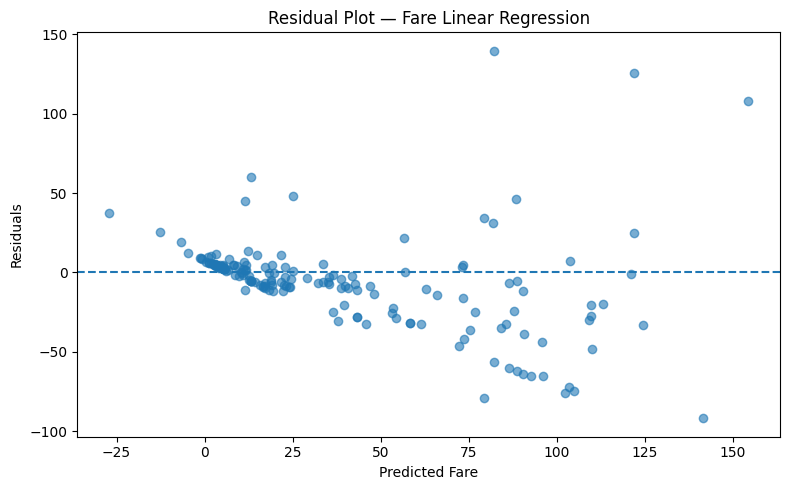

In [82]:
plt.figure(figsize=(8, 5))

plt.scatter(
    reg_y_pred,
    reg_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Linear Regression")

plt.tight_layout()
plt.show()

### Heteroscedasticity statement

In [83]:
print("\nHeteroscedasticity Interpretation:")
print(
    '''Inspect the residual plot for a systematic change in the spread of residuals. 
    A random and approximately constant spread around zero suggests no obvious heteroscedasticity, whereas a funnel-shaped or systematically changing spread indicates heteroscedasticity.'''
)


Heteroscedasticity Interpretation:
Inspect the residual plot for a systematic change in the spread of residuals. 
    A random and approximately constant spread around zero suggests no obvious heteroscedasticity, whereas a funnel-shaped or systematically changing spread indicates heteroscedasticity.


## Model Comparison

In [84]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_y_pred),
        accuracy_score(y_test, dt_y_pred),
        accuracy_score(y_test, rf_y_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_y_pred),
        precision_score(y_test, dt_y_pred),
        precision_score(y_test, rf_y_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_y_pred),
        recall_score(y_test, dt_y_pred),
        recall_score(y_test, rf_y_pred)
    ],

    "F1": [
        f1_score(y_test, lr_y_pred),
        f1_score(y_test, dt_y_pred),
        f1_score(y_test, rf_y_pred)
    ],

    "AUC": [
        roc_auc_score(y_test, lr_y_proba),
        roc_auc_score(y_test, dt_y_proba),
        roc_auc_score(y_test, rf_y_proba)
    ]
})

In [85]:
regression_result = pd.DataFrame({
    "Model": ["Linear Regression"],

    "Accuracy": [np.nan],
    "Precision": [np.nan],
    "Recall": [np.nan],
    "F1": [np.nan],
    "AUC": [np.nan],

    "MAE": [reg_mae],
    "RMSE": [reg_rmse],
    "R²": [reg_r2],
    "Adjusted R²": [reg_adjusted_r2]
})

In [86]:
classification_results["MAE"] = np.nan
classification_results["RMSE"] = np.nan
classification_results["R²"] = np.nan
classification_results["Adjusted R²"] = np.nan

In [87]:
model_comparison = pd.concat(
    [
        classification_results,
        regression_result
    ],
    ignore_index=True
)

In [88]:
model_comparison = model_comparison[
    [
        "Model",

        # Classification metrics
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",

        # Regression metrics
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ]
]

In [89]:
print("MODEL COMPARISON")
print("=" * 80)

display(
    model_comparison.round(4)
)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic Regression,0.7989,0.7797,0.6667,0.7188,0.8194,NaN,NaN,NaN,NaN
1,Decision Tree,0.7709,0.7059,0.6957,0.7007,0.7514,NaN,NaN,NaN,NaN
2,Random Forest,0.7821,0.7500,0.6522,0.6977,0.8184,NaN,NaN,NaN,NaN
3,Linear Regression,NaN,NaN,NaN,NaN,NaN,17.2612,28.9992,0.4565,0.3594


In [90]:

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_auc = roc_auc_score(y_test, rf_y_proba)

print("\nFINAL RECOMMENDATION")
print("=" * 80)

print(
    f"Random Forest is selected as the classifier to proceed with. "
    f"It achieved an accuracy of {rf_accuracy:.4f}, precision of "
    f"{rf_precision:.4f}, recall of {rf_recall:.4f}, and an F1 score "
    f"of {rf_f1:.4f}. Its ROC-AUC score was {rf_auc:.4f}, providing "
    f"an additional measure of its ability to distinguish between "
    f"the two classes. These metrics will be considered together "
    f"for the final Random Forest pipeline used in deployment."
)


FINAL RECOMMENDATION
Random Forest is selected as the classifier to proceed with. It achieved an accuracy of 0.7821, precision of 0.7500, recall of 0.6522, and an F1 score of 0.6977. Its ROC-AUC score was 0.8184, providing an additional measure of its ability to distinguish between the two classes. These metrics will be considered together for the final Random Forest pipeline used in deployment.


## Pipeline

In [92]:
full_pipeline = grid_search.best_estimator_

In [93]:
pipeline_path = "titanic_random_forest_pipeline.joblib"

joblib.dump(
    full_pipeline,
    pipeline_path
)

print(
    f"Complete Random Forest pipeline saved to: {pipeline_path}"
)

Complete Random Forest pipeline saved to: titanic_random_forest_pipeline.joblib


In [94]:

loaded_pipeline = joblib.load(
    pipeline_path
)

print("Pipeline successfully reloaded.")


Pipeline successfully reloaded.


In [95]:
print("\nLoaded Pipeline:")
print(loaded_pipeline)


Loaded Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_

In [96]:
loaded_rf_predictions = loaded_pipeline.predict(
    x_test
)


In [97]:
print("\nFirst 10 predictions from reloaded pipeline:")

print(
    loaded_rf_predictions[:10]
)



First 10 predictions from reloaded pipeline:
[0 0 0 0 1 1 1 0 0 0]


In [98]:
original_rf_predictions = full_pipeline.predict(
    x_test
)

predictions_match = np.array_equal(
    loaded_rf_predictions,
    original_rf_predictions
)

print(
    "\nReloaded predictions match original predictions:",
    predictions_match
)



Reloaded predictions match original predictions: True


In [99]:
loaded_accuracy = accuracy_score(
    y_test,
    loaded_rf_predictions
)

print(
    f"Accuracy of reloaded Random Forest pipeline: "
    f"{loaded_accuracy:.4f}"
)

Accuracy of reloaded Random Forest pipeline: 0.7989
